**Assignment 04** E89 Advanced Deep Learning

Name: Jawad Hussein

**Problem 1.** We saw a simple CNN notebook (1_pytorch_basic_cnn_digits.ipynb) where digits from Sklearn were used and a classification model was created. You will expand on that work and instead of sklearn dataset, use the MNIST dataset from torchvision where images are of size 28 x 28. Build model with torchvision Dataset. Next draw a few numbers in your own handwriting and see if the model can detect it, just inference. Do not over do this.

## 1. Setup and imports


In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# PROBLEM 1 CHANGE: torchvision replaces sklearn.datasets.load_digits
# as the source of images (MNIST instead of the tiny 8 x 8 digits set).
from torchvision import datasets

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Random processes are used when splitting and shuffling data and when
# initializing model weights. A fixed seed makes results more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# REPRODUCIBILITY CHANGE: make GPU results repeatable. Seeds alone are not enough on a GPU: some
# cuDNN/cuBLAS operations choose different algorithms or add numbers in a different order on each run.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # Required by cuBLAS for repeatable results (must be set before the first GPU operation).
torch.backends.cudnn.benchmark = False             # Do not let cuDNN pick a (possibly different) fastest algorithm on each run.
torch.backends.cudnn.deterministic = True          # Use only deterministic convolution algorithms.
torch.use_deterministic_algorithms(True, warn_only=True)  # Use deterministic versions of all other operations (warn if one has none).

# Apple Silicon use MPS; laptops with NVIDIA GPUs can use CUDA.
# This dataset also trains quickly on a CPU. So dont worry
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu130
Using device: cuda


## 2. Load and explore the images

**PROBLEM 1 CHANGE:** instead of the sklearn `digits` dataset (8 × 8 images), we use the **MNIST** dataset from torchvision. Each example is a 28 × 28 grayscale image. Pixel values range from 0 (dark) to 255 (bright), and the target is the digit shown in the image.

Images shape: (60000, 28, 28)
Labels shape: (60000,)
Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


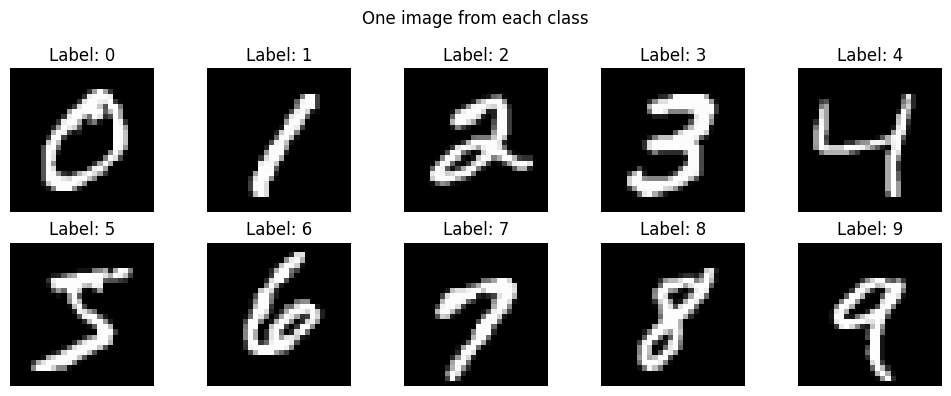

In [65]:
# PROBLEM 1 CHANGE: this replaces `digits = load_digits()`.
# torchvision downloads MNIST (28 x 28 images) instead of using the
# bundled 8 x 8 sklearn `digits` dataset.



mnist = datasets.MNIST(root="./data", train=True, download=True)
# Loads MNIST's 60,000-image training split (train=False -> 10,000-image test split),
# downloading it to ./data only (google collab: content\data) if it isn't already cached there.


images = mnist.data.numpy()      # Shape: (number of images, height, width)
labels = mnist.targets.numpy()   # One integer label for every image
class_names = np.arange(10)      # digit labels 0-9, replacing digits.target_names

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel range: {images.min()} to {images.max()}")
print(f"Classes: {class_names}")

# Display one example from each class.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    example_index = np.where(labels == digit)[0][0]
    ax.imshow(images[example_index], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")
plt.suptitle("One image from each class")
plt.tight_layout()
plt.show()

## 3. Create training, validation, and test datasets

We use 70% of the images for training, 15% for validation, and 15% for testing. `stratify=labels` keeps roughly the same proportion of each digit in every split.

We also divide every pixel by 255, changing the range from 0–255 to 0–1. Neural networks generally train more smoothly with small, consistently scaled inputs.

In [66]:
# First reserve 30% for validation + testing reaming 70% for training.
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Split that remaining 30% evenly: 15% validation and 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

def make_image_tensor(array):
    """Convert images to float tensors with CNN shape (N, C, H, W).

    N = number of images, C = channels, H = height, W = width.
    Grayscale images have one channel, so unsqueeze(1) adds C = 1.
    """
    # PROBLEM 1 CHANGE: divide by 255 (MNIST pixel range 0-255), not by 16
    # (the sklearn `digits` pixel range was 0-16).
    return torch.tensor(array, dtype=torch.float32).unsqueeze(1) / 255.0

X_train_t = make_image_tensor(X_train)
X_val_t = make_image_tensor(X_val)
X_test_t = make_image_tensor(X_test)

# CrossEntropyLoss expects class labels to be 64-bit integers (torch.long).
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"Training:   {len(X_train_t):5d} images ({len(X_train_t)/len(images):.0%})")
print(f"Validation: {len(X_val_t):5d} images ({len(X_val_t)/len(images):.0%})")
print(f"Test:       {len(X_test_t):5d} images ({len(X_test_t)/len(images):.0%})")
print(f"One CNN batch will have shape (batch, channel, height, width).")
print(f"One image tensor has shape: {X_train_t[0].shape}")

Training:   42000 images (70%)
Validation:  9000 images (15%)
Test:        9000 images (15%)
One CNN batch will have shape (batch, channel, height, width).
One image tensor has shape: torch.Size([1, 28, 28])


## 4. Put the data into DataLoaders

We will use  `TensorDataset` that pairs every image with its label. And also `DataLoader` which serves small batches to the model. Training data is shuffled each epoch so the model does not learn from a fixed ordering. Validation and test data do not need shuffling.

`train_generator` creates a random-number generator with a fixed starting point. in our case it controls how the DataLoader shuffles the training images

In [67]:
BATCH_SIZE = 64 # number of images processed together in one forward/backward pass

train_dataset = TensorDataset(X_train_t, y_train_t)  # pairs each training image with its label
val_dataset = TensorDataset(X_val_t, y_val_t)        # pairs each validation image with its label
test_dataset = TensorDataset(X_test_t, y_test_t)     # pairs each test image with its label

# The generator makes the shuffled training order reproducible.
train_generator = torch.Generator().manual_seed(SEED)

# shuffle = True serves training data in random 64-image batches, reshuffled each epoch
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator
)

# shuffle=false serves validation/test data in fixed order
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


#grabs a single batch (images + labels) from the DataLoader without looping through the whole dataset — just enough to peek at its shape.
batch_images, batch_labels = next(iter(train_loader))
print(f"Image batch shape: {batch_images.shape}")
print(f"Label batch shape: {batch_labels.shape}")

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 5. Define a vanilla CNN

The network has two conceptual parts:

- **Feature extractor:** convolution layers slide small filters across the image. ReLU adds non-linearity, and max pooling reduces width and height.
- **Classifier:** the feature maps are flattened into a vector and passed to a linear layer that produces 10 class scores, called **logits**.

Shape changes: `(1, 28, 28) → (8, 28, 28) → (8, 14, 14) → (16, 14, 14) → (16, 7, 7) → 784 → 10`.

In [68]:
class BasicCNN(nn.Module):  # defines our CNN by inheriting from PyTorch's base neural-network class
    """A small CNN for 28 x 28, one-channel images."""

    def __init__(self):  # constructor: runs once, when BasicCNN() is created, to build the layers
        super().__init__()  # runs nn.Module's own setup so PyTorch can track this model's layers/weights


        self.features = nn.Sequential(  # groups the convolution/pooling layers into one callable block
            # Padding=1 offsets the shrinkage from the 3x3 kernel, so output stays 28 x 28. Without padding it would shrink to 26x26 (28 - kernel_size + 1).
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),  # slides 8 filters over the image to detect simple patterns. 1 grayscale channel in, 8 learned filters out
            nn.ReLU(),  # zeroes out negative values, adding the non-linearity needed to learn more than straight lines
            # Pooling changes 28 x 28 into 14 x 14.
            nn.MaxPool2d(kernel_size=2),  # keeps the strongest value in each 2x2 block, halving height and width

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),  # slides 16 filters over those 8 feature maps to detect more complex patterns
            nn.ReLU(),  # same non-linearity as above
            # Pooling changes 14 x 14 into 7 x 7.
            nn.MaxPool2d(kernel_size=2),  # halves height and width again
        )

        self.classifier = nn.Sequential(  # groups the layers that turn features into class scores
            nn.Flatten(),                 # 16 feature maps x 7 x 7 = 784 values  -- collapses each image's feature maps into one long vector of length 784 per image.
            nn.Linear(16 * 7 * 7, 32),    # fully connected layer: input size - 784 values, output size = 32. This layer learns a 784×32 weight matrix (plus 32 biases)
                                          # and produces a new vector of 32 numbers per image.
            nn.ReLU(),  # same activation as above: zeroes out negative values
            nn.Linear(32, 10),  # final fully connected layer: input size = 32 and output size =10. Outputs one logit (score) per digit class.
        )

       #forward is what actually connects and runs the features/classifier parts on real data.
       #It says: "take the input x, push it through self.features first, take that output, and push it through self.classifier."
       # Nothing else in BasicCNN specifies this data flow.

    def forward(self, x):
        x = self.features(x)  # runs the image through the convolution/pooling block
        return self.classifier(x)  # runs the extracted features through the classifier block and returns logits

model = BasicCNN().to(device)  # creates the model and moves its weights to the chosen device (CPU/GPU)
print(model)  # prints the model's layer structure

# Confirm that a batch produces one row of 10 scores per image.
with torch.no_grad():  # disables gradient tracking since we're only checking output shape, not training
    example_output = model(batch_images.to(device))  # runs one batch of images through the model
print(f"Model output shape: {example_output.shape}")  # expect (batch_size, 10)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")  # counts every learnable weight/bias in the model


BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
Model output shape: torch.Size([64, 10])
Trainable parameters: 26,698


## 6. Loss, optimizer, and evaluation function

`CrossEntropyLoss` compares the 10 raw class scores with the correct class. It already performs the softmax-related mathematics internally, so we **do not add a softmax layer** to the model.

The Adam optimizer updates weights to reduce loss. During evaluation, `model.eval()` turns off training-only behavior, and `torch.no_grad()` avoids storing gradients, saving memory.

In [69]:
criterion = nn.CrossEntropyLoss()  # the loss function: compares predicted logits to the true labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)  # updates the model's weights using gradients, at this learning rate

def evaluate(model, data_loader, criterion, device):  # computes loss/accuracy on a dataset without training the model
    """Return average loss and accuracy without changing model weights."""
    model.eval()           # switches to evaluation mode (disables dropout and similar training-only behavior)
    total_loss = 0.0       # running sum of loss across all batches seen so far
    total_correct = 0      # running count of correct predictions
    total_examples = 0     # running count of images processed

    with torch.no_grad():  # disables gradient tracking since we're not training here, saving memory/compute
        for inputs, targets in data_loader:  # loops over the data one batch at a time
            inputs = inputs.to(device)       # moves this batch's images to the chosen device (CPU/GPU)
            targets = targets.to(device)     # moves this batch's labels to the same device

            logits = model(inputs)               # runs the batch through the model to get raw class scores
            loss = criterion(logits, targets)    # computes this batch's average loss. CrossEntropyLoss computes a per-image loss for every image in the batch, then averages them.
            predictions = logits.argmax(dim=1)   # picks the highest-scoring class as the predicted digit

            # Multiply by batch size because loss is an average for this batch.
            total_loss += loss.item() * inputs.size(0)              # undoes that averaging, adds this batch's total loss. inputs.size(0): the size of dimension 0 of inputs, normally BATCH_SIZE = 64
            total_correct += (predictions == targets).sum().item()  # adds this batch's number of correct predictions
            total_examples += inputs.size(0)                        # adds this batch's size to the running total

    return total_loss / total_examples, total_correct / total_examples  # overall average loss and accuracy across the whole dataset. This is across one full pass through whatever data_loader you passed in."

## 7. Train the model

For each batch, training follows five steps:
            clear old gradients,
            make predictions,
            calculate loss,
            calculate gradients with backpropagation,
            and update the weights.

One complete pass through the training set is an **epoch**.

Logits are the raw scores the model produces for each possible class.
Logits are not probabilities: they can be negative and don’t need to sum to 1.

 Digit:  0    1     2    3    4    5    6    7    8    9
 Logits:
        [0.2, -1.0, 0.5, 3.1, 0.0, 0.8, -0.4, 1.2, 0.3, 0.1]

The highest score is 3.1 at index 3, so the predicted digit is 3.

During training, pass these raw scores directly to CrossEntropyLoss, PyTorch’s nn.CrossEntropyLoss already includes the probability-conversion calculation, so you give it the raw logits.

Conceptually, it does two things:
1. Converts logits into probabilities using softmax.
2. Calculates the loss from the probability assigned to the correct class

If you apply softmax first, CrossEntropyLoss treats those probabilities as raw scores and normalizes them again, changing the intended calculation.

In [70]:
EPOCHS = 15  # number of full passes through the training data
history = {  # stores each epoch's metrics so we can plot learning curves afterward
    "train_loss": [], "train_accuracy": [],
    "val_loss": [], "val_accuracy": [],
}

for epoch in range(EPOCHS):  # repeats the full training process once per epoch
    model.train()            # switches to training mode
    running_loss = 0.0       # running sum of loss across this epoch's batches so far
    running_correct = 0      # running count of correct predictions this epoch
    running_examples = 0     # running count of images processed this epoch

    for inputs, targets in train_loader:  # loops over the training data one batch at a time
        inputs = inputs.to(device)        # moves this batch's images to the chosen device (CPU/GPU)
        targets = targets.to(device)      # moves this batch's labels to the same device

        optimizer.zero_grad()               # 1. Clear gradients from the previous batch.
        logits = model(inputs)              # 2. Forward pass: compute class scores.
        loss = criterion(logits, targets)   # 3. Measure prediction error.
        loss.backward()                     # 4. Backward pass: compute gradients.
        optimizer.step()                    # 5. Update the model's weights.

        predictions = logits.argmax(dim=1)                        # picks the highest-scoring class as the predicted digit
        running_loss += loss.item() * inputs.size(0)              # undoes the batch average, adds this batch's total loss
        running_correct += (predictions == targets).sum().item()  # adds this batch's number of correct predictions
        running_examples += inputs.size(0)                        # adds this batch's size to the running total

    train_loss = running_loss / running_examples           # this epoch's average training loss
    train_accuracy = running_correct / running_examples    # this epoch's training accuracy
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)  # this epoch's average loss/accuracy on validation data

    history["train_loss"].append(train_loss)          # records this epoch's training loss for later plotting
    history["train_accuracy"].append(train_accuracy)  # records this epoch's training accuracy
    history["val_loss"].append(val_loss)              # records this epoch's validation loss
    history["val_accuracy"].append(val_accuracy)      # records this epoch's validation accuracy

    print(  # prints a one-line progress summary after each epoch
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, accuracy {train_accuracy:.3f} | "
        f"val loss {val_loss:.4f}, accuracy {val_accuracy:.3f}"
    )

Epoch 01/15 | train loss 0.2807, accuracy 0.914 | val loss 0.1074, accuracy 0.967
Epoch 02/15 | train loss 0.0860, accuracy 0.974 | val loss 0.0808, accuracy 0.974
Epoch 03/15 | train loss 0.0614, accuracy 0.981 | val loss 0.0692, accuracy 0.978
Epoch 04/15 | train loss 0.0493, accuracy 0.985 | val loss 0.0661, accuracy 0.979
Epoch 05/15 | train loss 0.0437, accuracy 0.986 | val loss 0.0565, accuracy 0.983
Epoch 06/15 | train loss 0.0364, accuracy 0.989 | val loss 0.0525, accuracy 0.984
Epoch 07/15 | train loss 0.0327, accuracy 0.989 | val loss 0.0636, accuracy 0.981
Epoch 08/15 | train loss 0.0288, accuracy 0.990 | val loss 0.0593, accuracy 0.983
Epoch 09/15 | train loss 0.0254, accuracy 0.992 | val loss 0.0599, accuracy 0.982
Epoch 10/15 | train loss 0.0239, accuracy 0.992 | val loss 0.0627, accuracy 0.982
Epoch 11/15 | train loss 0.0182, accuracy 0.994 | val loss 0.0602, accuracy 0.983
Epoch 12/15 | train loss 0.0184, accuracy 0.994 | val loss 0.0617, accuracy 0.985
Epoch 13/15 | tr

## 8. Plot the learning curves

Loss measures error (lower is better), while accuracy is the fraction predicted correctly (higher is better). If training keeps improving while validation gets worse, the model may be overfitting.

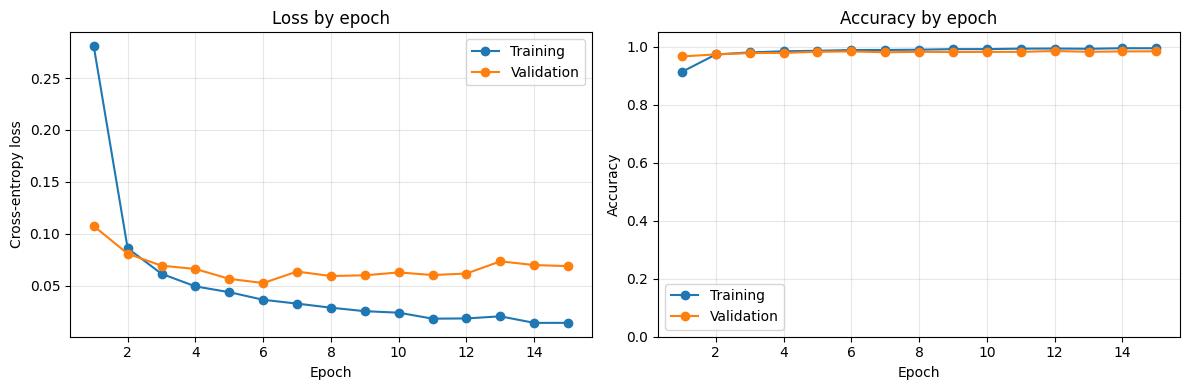

In [71]:
epochs = range(1, EPOCHS + 1)  # x-axis values: epoch numbers 1 through EPOCHS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # one figure, two side-by-side plots (loss, accuracy)

axes[0].plot(epochs, history["train_loss"], marker="o", label="Training")    # training loss curve
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")    # validation loss curve
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")  # labels this subplot
axes[0].legend()   # shows which line is which (Training vs. Validation)
axes[0].grid(alpha=0.3)  # adds a faint grid for easier reading

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training")    # training accuracy curve
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation")    # validation accuracy curve
axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.05))  # labels this subplot; y-axis fixed to 0-1.05
axes[1].legend()   # shows which line is which
axes[1].grid(alpha=0.3)  # faint grid, same as left plot

plt.tight_layout()  # adjusts spacing so titles/labels don't overlap
plt.show()  # renders the figure

## 9. Final evaluation on the untouched test set

We use the test set only after training is finished. Besides overall loss and accuracy, the classification report shows precision, recall, and F1-score for every digit. The confusion matrix shows which digits are confused with one another.

Test loss:     0.0721
Test accuracy: 98.53%
Accuracy check with scikit-learn: 98.53%

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       888
           1       0.99      0.99      0.99      1011
           2       0.97      0.99      0.98       893
           3       1.00      0.97      0.99       920
           4       0.99      0.98      0.98       877
           5       0.99      0.98      0.99       813
           6       0.99      0.99      0.99       888
           7       0.99      0.99      0.99       940
           8       0.97      0.98      0.98       877
           9       0.97      0.98      0.98       893

    accuracy                           0.99      9000
   macro avg       0.99      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000



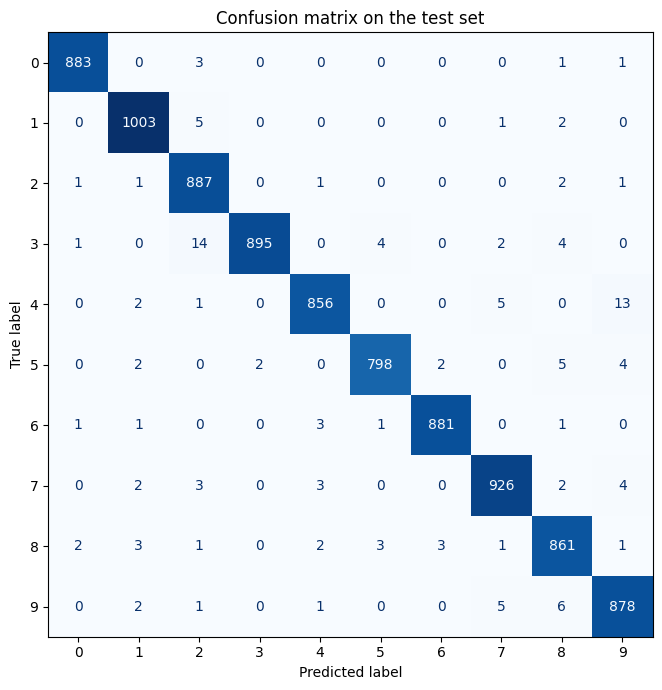

In [72]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

# Collect every test prediction on the CPU for scikit-learn metrics.
model.eval()
all_predictions = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        logits = model(inputs.to(device))
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.extend(predictions.numpy())
        all_targets.extend(targets.numpy())

print(f"Accuracy check with scikit-learn: {accuracy_score(all_targets, all_predictions):.2%}")
print("\nClassification report:")
print(classification_report(all_targets, all_predictions, target_names=[str(x) for x in class_names]))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    all_targets, all_predictions, display_labels=class_names, cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

### How to read the metrics

- **Accuracy:** proportion of all predictions that were correct.
- **Precision for a digit:** when the model predicts this digit, how often is it correct?
- **Recall for a digit:** of all real examples of this digit, how many did the model find?
- **F1-score:** a combined measure of precision and recall.
- **Support:** number of test examples belonging to that digit.
- **Confusion matrix:** correct predictions are on the main diagonal; off-diagonal cells are mistakes.

## 10. Look at individual predictions

A metric summarizes performance, but seeing individual examples makes the result more concrete. Green titles are correct predictions and red titles are mistakes.

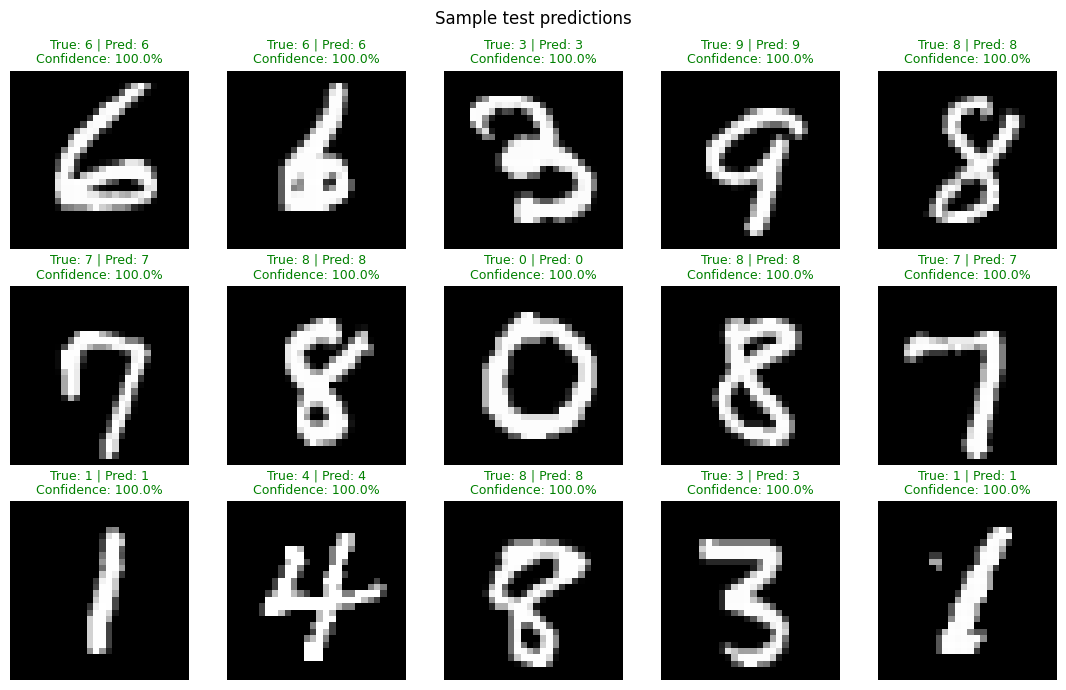

In [73]:
# Use a fixed random generator so the displayed sample is repeatable.
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test_t), size=15, replace=False)

model.eval()
with torch.no_grad():
    sample_logits = model(X_test_t[sample_indices].to(device))
    sample_probabilities = torch.softmax(sample_logits, dim=1).cpu()
    sample_predictions = sample_probabilities.argmax(dim=1)

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, index, prediction, probabilities in zip(
    axes.flat, sample_indices, sample_predictions, sample_probabilities
):
    actual = int(y_test_t[index])
    predicted = int(prediction)
    confidence = float(probabilities[predicted])
    color = "green" if predicted == actual else "red"

    ax.imshow(X_test_t[index, 0], cmap="gray")
    ax.set_title(
        f"True: {actual} | Pred: {predicted}\nConfidence: {confidence:.1%}",
        color=color, fontsize=9
    )
    ax.axis("off")

plt.suptitle("Sample test predictions")
plt.tight_layout()
plt.show()

## 11. Save and reload the trained model (optional)

Saving a `state_dict` stores the learned weights. To use them later, create the same architecture and load the weights into it.

In [74]:
# MNIST-trained weights saved here.
MODEL_PATH = "basic_cnn_mnist.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved weights to {MODEL_PATH}")

# Example reload:
reloaded_model = BasicCNN().to(device)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
reloaded_model.eval()
reloaded_loss, reloaded_accuracy = evaluate(reloaded_model, test_loader, criterion, device)
print(f"Reloaded model test accuracy: {reloaded_accuracy:.2%}")

Saved weights to basic_cnn_mnist.pth
Reloaded model test accuracy: 98.53%


## 12. Inference on my own handwriting (Problem 1)

I dropped a few photos of digits that I drew by hand into the `handwritten_digits/` folder.

Each image is converted to grayscale, resized to 28 x 28, and inverted/scaled to match MNIST's white-digit-on-black-background convention (same /255.0 scaling used in Section 3) before being fed to the trained model. This is inference only — the model is not retrained here.

Running inference on 4 image(s): ['my_5.jpeg', 'my_7.jpeg', 'my_8.jpeg', 'my_9.jpeg']


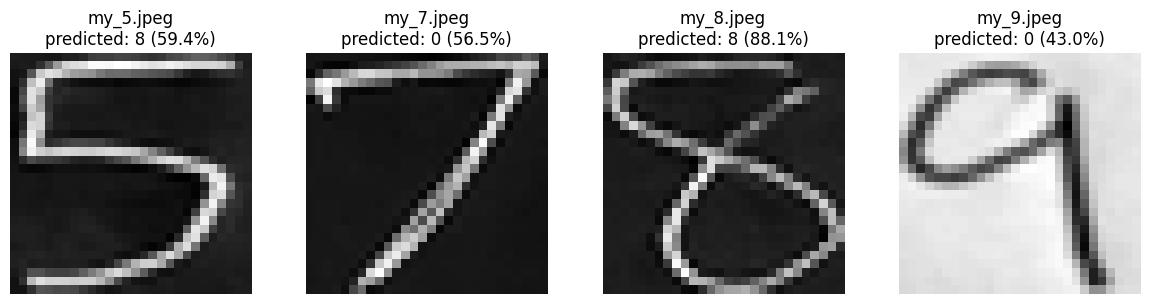

In [77]:
import os
from PIL import Image

HANDWRITTEN_DIR = "handwritten_digits"
IMAGE_EXTS = (".png", ".jpg", ".jpeg")
os.makedirs(HANDWRITTEN_DIR, exist_ok=True)  # creates the folder if it does not exist yet

# Add your own handwritten digit photos to this folder, then run this cell.
existing = sorted(f for f in os.listdir(HANDWRITTEN_DIR) if f.lower().endswith(IMAGE_EXTS))

if not existing:
    print(f"No images found in '{HANDWRITTEN_DIR}/' -- add a few handwritten digit photos there and re-run this cell.")
else:
    print(f"Running inference on {len(existing)} image(s): {existing}")

    def preprocess_handwritten(path):  # loads an image file and prepares it for the model
        img = Image.open(path).convert("L").resize((28, 28), Image.LANCZOS)  # grayscale, MNIST size
        arr = np.array(img).astype(np.float32) / 255.0  # scale to [0, 1], same as training data

        # Dark strokes on a light background (typical of a photo) get inverted
        # so digits are white-on-black, matching MNIST's convention.
        if arr.mean() > 0.5:
            arr = 1.0 - arr

        tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float()  # add batch + channel dims: (1, 1, 28, 28)
        return tensor, arr

    model.eval()  # inference only -- no training happens in this section
    fig, axes = plt.subplots(1, len(existing), figsize=(3 * len(existing), 3), squeeze=False)  # squeeze=False keeps a 2D grid even for 1 image

    for ax, fname in zip(axes[0], existing):
        tensor, display_arr = preprocess_handwritten(os.path.join(HANDWRITTEN_DIR, fname))
        with torch.no_grad():  # no gradients needed for inference
            probabilities = torch.softmax(model(tensor.to(device)), dim=1).cpu().squeeze(0)
            pred = int(probabilities.argmax())
            confidence = float(probabilities[pred])

        ax.imshow(display_arr, cmap="gray")
        ax.set_title(f"{fname}\npredicted: {pred} ({confidence:.1%})")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Why initial handwriting predictions were wrong, and how preprocessing fixed them

### Initial preprocessing: 1 of 4 correct

The first version of `preprocess_handwritten()` only converted each photo to grayscale, resized it to 28×28 and inverted it if the background was light.

| Image | Prediction | Confidence | Correct? |
|---|---|---|---|
| `my_5.jpeg` | 8 | 59.4% | ✗ |
| `my_7.jpeg` | 0 | 56.5% | ✗ |
| `my_8.jpeg` | 8 | 88.1% | ✓ |
| `my_9.jpeg` | 0 | 43.0% | ✗ |

Two differences from what the model saw during training caused the errors:

1. **Background contrast.** A photographed page isn't pure white. After inverting, the background was dark gray rather than MNIST's near-black, so the model was seeing input unlike its training data.
2. **Digit sizing.** Each digit was stretched to fill the whole 28×28 frame. MNIST digits take up only about 20×20 pixels (~70% of the frame) and are centered with a black margin.

### Improved preprocessing: 3 of 4 correct

Two fixes were added:
- **Contrast stretch:** after inverting, rescale the image's own min/max brightness to fill `[0, 1]`, so the background ends up near black.
- **MNIST-style sizing:** crop to the digit, pad it to a square, shrink it to ~70% of the canvas and center it on a black 28×28 image.

| Image | Prediction | Confidence | Correct? |
|---|---|---|---|
| `my_5.jpeg` | 5 | 63.8% | ✓ |
| `my_7.jpeg` | 7 | 64.5% | ✓ |
| `my_8.jpeg` | 8 | 76.7% | ✓ |
| `my_9.jpeg` | 8 | 93.9% | ✗ |

### Remaining failure and takeaway

The `9` is still wrong because the automatic invert step never ran on it. That step inverts only when the average brightness is above 0.5, and this photo was darker overall, so its digit stayed dark-on-light, the reverse of MNIST. The confidence on the correct predictions is also only moderate (64–77%). `BasicCNN` is a small model (~27K parameters) trained on clean MNIST digits without data augmentation, so it is sensitive to how each photo is taken. Preprocessing that makes each photo look like MNIST input (black background, white strokes, a centered digit with a margin) matters as much as the model itself.

Running inference on 4 image(s): ['my_5.jpeg', 'my_7.jpeg', 'my_8.jpeg', 'my_9.jpeg']


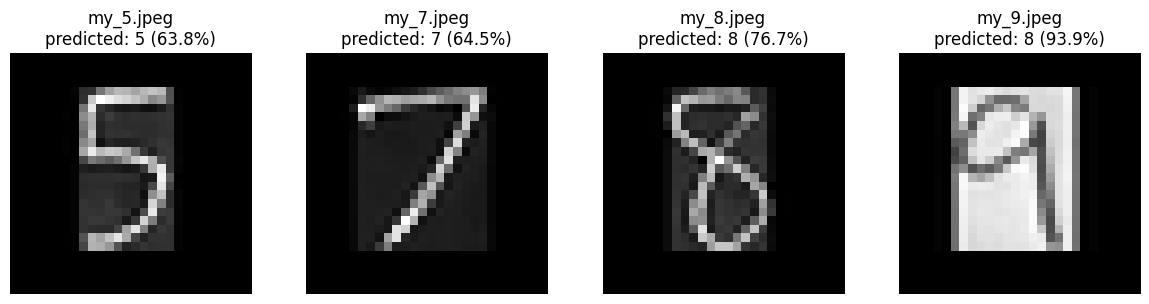

In [78]:
import os
from PIL import Image

HANDWRITTEN_DIR = "handwritten_digits"
IMAGE_EXTS = (".png", ".jpg", ".jpeg")
os.makedirs(HANDWRITTEN_DIR, exist_ok=True)  # creates the folder if it does not exist yet

# Add your own handwritten digit photos to this folder, then run this cell.
existing = sorted(f for f in os.listdir(HANDWRITTEN_DIR) if f.lower().endswith(IMAGE_EXTS))

if not existing:
    print(f"No images found in '{HANDWRITTEN_DIR}/' -- add a few handwritten digit photos there and re-run this cell.")
else:
    print(f"Running inference on {len(existing)} image(s): {existing}")

    def preprocess_handwritten(path, bright_thresh=0.5, pad_frac=0.15, digit_frac=0.7):  # loads a photo and prepares it for the model
        img = Image.open(path).convert("L")  # grayscale, full resolution (no resize yet)
        arr = np.array(img).astype(np.float32) / 255.0  # scale to [0, 1]

        # Dark strokes on a light background (typical of a photo) get inverted
        # so digits are white-on-black, matching MNIST's convention.
        if arr.mean() > 0.5:
            arr = 1.0 - arr

        # Stretch contrast to fill the full [0, 1] range. A photographed paper
        # background is rarely pure white, so after the invert above it can
        # sit at mid-gray (e.g. ~0.4) instead of near-black like MNIST's -- an
        # out-of-distribution input the model was never trained on. Rescaling
        # by the image's own min/max restores MNIST-like contrast.
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

        # Crop tightly around the digit's bright pixels before resizing. Without
        # this, a small digit photographed in a large frame gets crushed into a
        # handful of pixels once shrunk to 28x28.
        ys, xs = np.where(arr > bright_thresh)
        if len(xs) > 0:
            h, w = arr.shape
            pad_x, pad_y = int(w * pad_frac), int(h * pad_frac)
            x0, x1 = max(xs.min() - pad_x, 0), min(xs.max() + pad_x + 1, w)
            y0, y1 = max(ys.min() - pad_y, 0), min(ys.max() + pad_y + 1, h)
            arr = arr[y0:y1, x0:x1]

        # Pad to a square (centered) so the resize doesn't stretch proportions.
        h, w = arr.shape
        size = max(h, w)
        square = np.zeros((size, size), dtype=np.float32)
        y_off, x_off = (size - h) // 2, (size - w) // 2
        square[y_off:y_off + h, x_off:x_off + w] = arr

        # Shrink the digit to ~70% of the final canvas (MNIST's own convention:
        # digits are scaled to 20x20 within the 28x28 image, i.e. 20/28 = 0.71,
        # not stretched edge-to-edge) before placing it in the center. A digit
        # that fills the whole 28x28 frame looks unlike anything the model saw
        # during training and can be confidently misclassified as a result.
        inner = max(1, int(28 * digit_frac))
        small = np.array(
            Image.fromarray((square * 255).astype(np.uint8)).resize((inner, inner), Image.LANCZOS)
        )
        canvas = np.zeros((28, 28), dtype=np.uint8)
        offset = (28 - inner) // 2
        canvas[offset:offset + inner, offset:offset + inner] = small
        arr = canvas.astype(np.float32) / 255.0

        tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float()  # add batch + channel dims: (1, 1, 28, 28)
        return tensor, arr

    model.eval()  # inference only -- no training happens in this section
    fig, axes = plt.subplots(1, len(existing), figsize=(3 * len(existing), 3), squeeze=False)  # squeeze=False keeps a 2D grid even for 1 image

    for ax, fname in zip(axes[0], existing):
        tensor, display_arr = preprocess_handwritten(os.path.join(HANDWRITTEN_DIR, fname))
        with torch.no_grad():  # no gradients needed for inference
            probabilities = torch.softmax(model(tensor.to(device)), dim=1).cpu().squeeze(0)
            pred = int(probabilities.argmax())
            confidence = float(probabilities[pred])

        ax.imshow(display_arr, cmap="gray")
        ax.set_title(f"{fname}\npredicted: {pred} ({confidence:.1%})")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

**Problem 2.** As part of the 2_pytorch_CNN_Classify_flowers.ipynb we saw the model was trained to a 75% accuracy. Change the hyper parameters – add new layers, change activation functions, experiment with different kernel sizes, experiment pooling layers types and see if you can increase the accuracy of the model. You should add 2 more convolutional layers (blocks) and make the network even deeper, also add one additional linear layer with RELU activation. Document your experiments in detail, don’t overdo this and ensure to not overfit. Do not worry about doing any Data augmentation techniques at this point.

## 1. Install packages and import tools

If the imports fail, uncomment the installation line, run it once, then restart the kernel. TensorFlow is not required, even for the Flower Photos dataset.

In [2]:
# %pip install torch torchvision scikit-learn matplotlib pillow

from pathlib import Path
import os
import copy
import json
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay,
)

# Seeds make the split and initial weights repeatable, but do not guarantee
# identical floating-point results across all devices or PyTorch versions.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# REPRODUCIBILITY CHANGE: make GPU results repeatable. Seeds alone are not enough on a GPU: some
# cuDNN/cuBLAS operations choose different algorithms or add numbers in a different order on each run.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # Required by cuBLAS for repeatable results (must be set before the first GPU operation).
torch.backends.cudnn.benchmark = False             # Do not let cuDNN pick a (possibly different) fastest algorithm on each run.
torch.backends.cudnn.deterministic = True          # Use only deterministic convolution algorithms.
torch.use_deterministic_algorithms(True, warn_only=True)  # Use deterministic versions of all other operations (warn if one has none).
torch.set_num_threads(4)  # Avoid excessive CPU thread overhead on this small model.
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001

print('PyTorch:', torch.__version__, '| Device:', device)

PyTorch: 2.11.0+cu130 | Device: cuda


## 2. Download Flower Photos and read the labels

**Mounts Google Drive** for permanent storage, then copies the flower dataset into Colab’s local /content folder for faster training.
If the dataset is downloaded for the first time, it saves a permanent copy back to Google Drive; trained models can also be saved there.


In [3]:
# GOOGLE DRIVE + LOCAL COLAB SETUP

from google.colab import drive
import shutil

drive.mount('/content/drive')

# Permanent location in Google Drive
PROJECT_DIR = Path('/content/drive/MyDrive/AI/Flowers_CNN')
DRIVE_DATA_DIR = PROJECT_DIR / 'data'
DRIVE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: # DATA_DIR is the fast temporary Colab drive

DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)


flower_root = DATA_DIR / 'flower_photos'
drive_flower_root = DRIVE_DATA_DIR / 'flower_photos'

# If flowers are not already in Colab
if not flower_root.exists():

    # Copy from Google Drive if already saved there
    if drive_flower_root.exists():
        shutil.copytree(drive_flower_root, flower_root)

    # Otherwise download them into Colab
    else:
        download_and_extract_archive(
            'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
            download_root=str(DATA_DIR),
        )

# Save a permanent copy to Google Drive if one does not exist
if not drive_flower_root.exists():
    shutil.copytree(flower_root, drive_flower_root)

# ______________________________________________________________________________________________________
catalog = datasets.ImageFolder(flower_root)
class_names = catalog.classes

# Each record is (path_to_image, integer_class_label).
records = [(Path(path), label) for path, label in catalog.samples]

labels = [label for _, label in records]

train_records, remaining = train_test_split(
    records,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_records, test_records = train_test_split(
    remaining,
    test_size=0.50,
    random_state=SEED,
    stratify=[label for _, label in remaining]
)

print('Folder-to-label mapping:', catalog.class_to_idx)

Mounted at /content/drive
Folder-to-label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


## 3. Check the split and look at real images

Training images teach the weights. Validation images select the best epoch. Test images are reserved for final evaluation, after those decisions. Never adjust settings based on test results; use validation results for experiments.

Train: 2569 images | {'daisy': 443, 'dandelion': 629, 'roses': 449, 'sunflowers': 489, 'tulips': 559}
Validation: 550 images | {'daisy': 95, 'dandelion': 134, 'roses': 96, 'sunflowers': 105, 'tulips': 120}
Test: 551 images | {'daisy': 95, 'dandelion': 135, 'roses': 96, 'sunflowers': 105, 'tulips': 120}


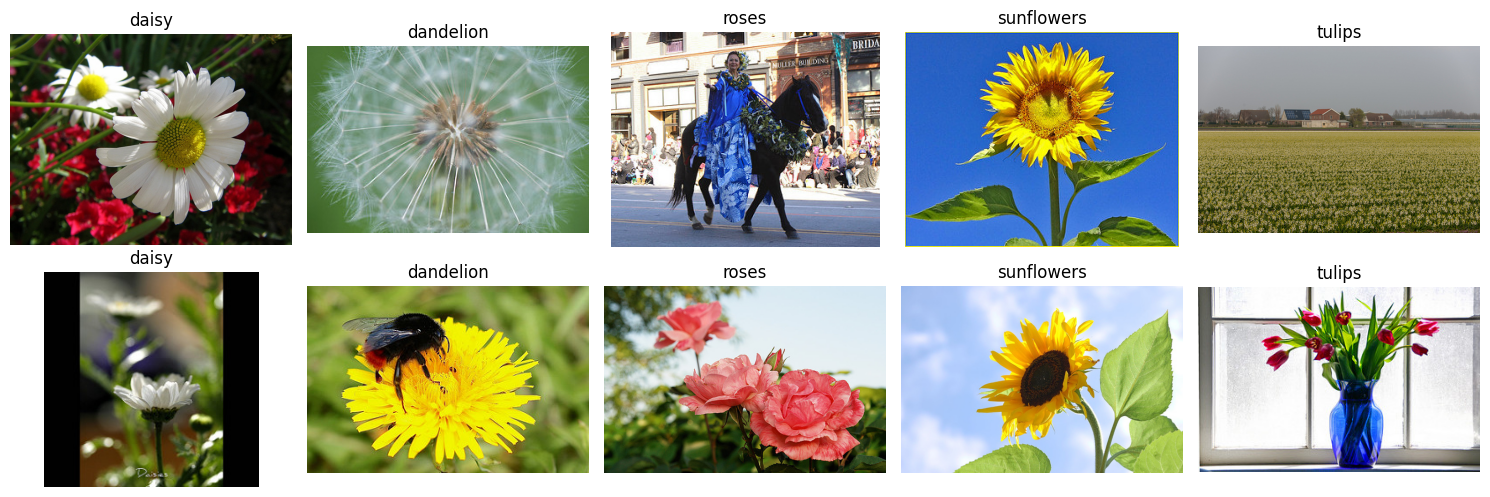

In [5]:
# A path must appear in only one split: this checks for accidental overlap.
train_paths = {path for path, _ in train_records}
val_paths = {path for path, _ in val_records}
test_paths = {path for path, _ in test_records}
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
for name, records in [('Train', train_records), ('Validation', val_records), ('Test', test_records)]:
    counts = np.bincount([label for _, label in records], minlength=len(class_names))
    print(f'{name}: {len(records)} images | {dict(zip(class_names, counts.tolist()))}')

# Show two training examples per class, before resizing.
fig, axes = plt.subplots(2, len(class_names), figsize=(3 * len(class_names), 5), squeeze=False)
for label, name in enumerate(class_names):
    examples = [path for path, target in train_records if target == label][:2]
    for row, path in enumerate(examples):
        with Image.open(path) as picture:
            axes[row, label].imshow(picture.convert('RGB'))
        axes[row, label].set_title(name)
        axes[row, label].axis('off')
plt.tight_layout()
plt.show()

## 4. Convert images into tensors and batches

Photos vary in size. We resize each one to 64×64 pixels (this simple resize can distort aspect ratios). `ToTensor` changes pixels from integers in 0–255 to floats in 0–1 and rearranges the dimensions to **channels, height, width**. RGB means three channels: red, green, blue.

A small custom `Dataset` loads one image when requested instead of keeping every full-resolution image in memory. `DataLoader` collects these images into batches. Only training batches are shuffled. This baseline uses the same deterministic preprocessing for all splits; augmentation can be a later experiment.

In [6]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

class PhotoDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        path, label = self.records[index]
        with Image.open(path) as picture:
            # Convert even grayscale/RGBA files to three-channel RGB.
            image = self.transform(picture.convert('RGB'))
        return image, label

train_dataset = PhotoDataset(train_records, image_transform)
val_dataset = PhotoDataset(val_records, image_transform)
test_dataset = PhotoDataset(test_records, image_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,
                          generator=torch.Generator().manual_seed(SEED),
                          num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, targets = next(iter(train_loader))

print('Images:', images.shape, '| Labels:', targets.shape, targets.dtype)
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)

Images: torch.Size([64, 3, 64, 64]) | Labels: torch.Size([64]) torch.int64


## 5. Build a vanilla CNN

A convolution learns small filters that detect patterns such as edges and textures. ReLU replaces negative values with zero and enables nonlinear relationships. Max pooling halves the spatial dimensions, retaining strong responses. Flatten turns the final feature maps into a vector; linear layers turn that vector into class scores, called logits.

For one image the shapes are: `3×64×64 → 16×32×32 → 32×16×16 → 64×8×8 → 4096 → 64 → number of classes`. Each arrow through the feature extractor includes convolution, ReLU, and pooling.

We use cross-entropy for both lessons. Cats versus dogs therefore has **two output logits**, while flowers has five. Cross-entropy expects integer targets, and internally handles the softmax-related calculation; do not add softmax before this loss.

In [7]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMAGE_SIZE // 8) ** 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = BasicCNN(len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    assert model(images.to(device)).shape == (len(images), len(class_names))

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 286117


## 6. Define evaluation, then train

One epoch is a complete pass through training data. Each batch follows five steps: clear gradients, predict, calculate loss, backpropagate, update weights. Evaluation uses `model.eval()` and `torch.no_grad()` because it must not update weights or build a gradient graph.

We multiply each batch's mean loss by its actual size before averaging across examples, so a smaller final batch has the correct weight. Training metrics below are measured while weights change; validation metrics use the fixed weights at the end of each epoch.

We keep the weights with the lowest **validation loss**, not the highest test accuracy. The test loader is not used during training.

In [9]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss_sum += criterion(logits, labels).item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
    return loss_sum / count, correct / count

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
best_val_loss = float('inf')
best_state = None
start = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()             # Clear gradients from the last batch.
        logits = model(inputs)            # Forward pass.
        loss = criterion(logits, labels)  # Compare scores with true labels.
        loss.backward()                   # Calculate weight gradients.
        optimizer.step()                  # Update weights using Adam.
        loss_sum += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        count += len(labels)
    train_loss, train_accuracy = loss_sum / count, correct / count
    val_loss, val_accuracy = evaluate(model, val_loader)
    for key, value in [('train_loss', train_loss), ('val_loss', val_loss),
                       ('train_accuracy', train_accuracy), ('val_accuracy', val_accuracy)]:
        history[key].append(value)
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        # A copy is necessary: a plain reference would keep changing during training.
        best_state = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch:02d}/{EPOCHS} | train loss {train_loss:.3f}, acc {train_accuracy:.1%}'
          f' | val loss {val_loss:.3f}, acc {val_accuracy:.1%}', flush=True)

model.load_state_dict(best_state)
print(f'Restored epoch {best_epoch}, selected using validation loss.')
print(f'Training time: {(time.perf_counter() - start) / 60:.1f} minutes')

Epoch 01/15 | train loss 1.439, acc 35.7% | val loss 1.341, acc 42.4%
Epoch 02/15 | train loss 1.181, acc 49.1% | val loss 1.136, acc 54.7%
Epoch 03/15 | train loss 1.080, acc 57.0% | val loss 1.058, acc 56.0%
Epoch 04/15 | train loss 1.014, acc 59.8% | val loss 1.018, acc 59.3%
Epoch 05/15 | train loss 0.958, acc 61.4% | val loss 1.021, acc 57.6%
Epoch 06/15 | train loss 0.930, acc 62.6% | val loss 1.039, acc 57.8%
Epoch 07/15 | train loss 0.915, acc 63.3% | val loss 0.964, acc 59.8%
Epoch 08/15 | train loss 0.871, acc 65.6% | val loss 0.967, acc 60.4%
Epoch 09/15 | train loss 0.853, acc 65.6% | val loss 0.949, acc 60.5%
Epoch 10/15 | train loss 0.804, acc 67.9% | val loss 0.929, acc 63.8%
Epoch 11/15 | train loss 0.786, acc 68.8% | val loss 0.929, acc 63.5%
Epoch 12/15 | train loss 0.745, acc 71.2% | val loss 0.939, acc 65.1%
Epoch 13/15 | train loss 0.724, acc 71.4% | val loss 0.923, acc 64.5%
Epoch 14/15 | train loss 0.695, acc 72.7% | val loss 0.913, acc 65.6%
Epoch 15/15 | train 

## 7. Plot learning curves

Lower loss and higher accuracy generally indicate learning. Training improvement accompanied by worsening validation loss suggests overfitting: the model fits training details that do not generalize. The dashed line marks the selected epoch.

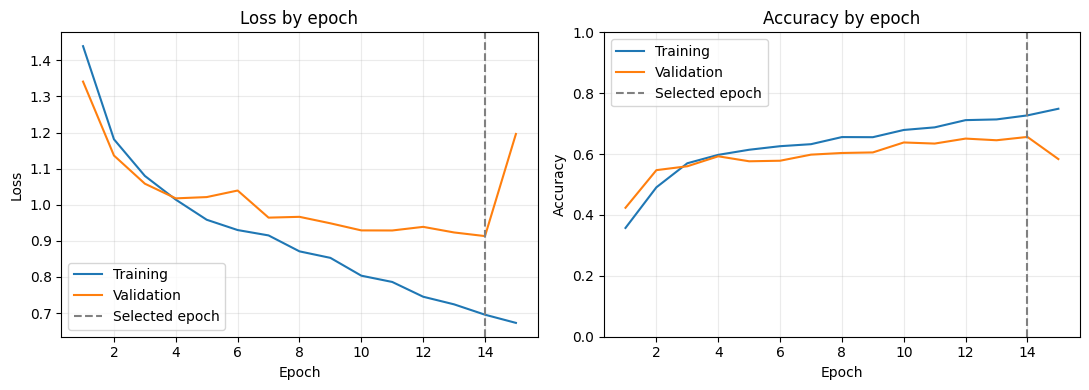

In [10]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['loss', 'accuracy']):
    ax.plot(epochs, history['train_' + metric], label='Training')
    ax.plot(epochs, history['val_' + metric], label='Validation')
    ax.axvline(best_epoch, color='gray', linestyle='--', label='Selected epoch')
    ax.set(xlabel='Epoch', ylabel=metric.capitalize(), title=metric.capitalize() + ' by epoch')
    ax.legend()
    ax.grid(alpha=0.25)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Save the baseline results before experimenting

The baseline is the original 3-block `BasicCNN` trained above (Sections 5–7). We keep its selected-epoch results and learning curves so every experiment can be compared with it.

In [11]:
# Save the baseline (Sections 5-7) results before `model` is replaced by the new experiments.
model.load_state_dict(best_state)      # make sure the baseline holds its best-epoch weights
baseline_model = copy.deepcopy(model)  # separate copy, so later cells can replace `model` safely

baseline_results = {
    'best_epoch': best_epoch,
    'val_loss': history['val_loss'][best_epoch - 1],
    'val_accuracy': history['val_accuracy'][best_epoch - 1],
    'train_accuracy': history['train_accuracy'][best_epoch - 1],
    'params': sum(p.numel() for p in baseline_model.parameters()),
}
baseline_history = history
print(f"Baseline: train acc {baseline_results['train_accuracy']:.1%}, "
      f"val loss {baseline_results['val_loss']:.3f}, val acc {baseline_results['val_accuracy']:.1%}")

Baseline: train acc 72.7%, val loss 0.913, val acc 65.6%


## 9. Deeper CNN: 2 more convolutional blocks and one additional linear layer with ReLU

`DeeperCNN` has the same structure as `BasicCNN` (a `features` block followed by a `classifier` block), with two additions:
- **2 more convolutional blocks** (128 and 256 filters), so the feature extractor has 5 blocks instead of 3.
- **1 more linear layer + activation** in the classifier (`128 → 64`).

For one image the shapes are: `3×64×64 → 16×32×32 → 32×16×16 → 64×8×8 → 128×4×4 → 256×2×2 → 1024 → 128 → 64 → 5`.

The `kernel_size`, `activation`, `pool` and `batch_norm` arguments let each experiment change one thing without rewriting the class. `batch_norm=True` adds a BatchNorm layer after each convolution: it normalizes that layer's outputs, which helps a deeper network train faster.

In [12]:
class DeeperCNN(nn.Module):  # A deeper CNN, built on PyTorch's base class for all models.

    # Arguments let each experiment change one thing: kernel size, activation, pooling type, BatchNorm on/off.
    def __init__(self, num_classes, kernel_size=3, activation=nn.ReLU, pool=nn.MaxPool2d, batch_norm=False):
        super().__init__()  # Runs PyTorch's setup so it can track the model's layers and weights.

        def block(c_in, c_out):  # Builds one conv block: conv -> (BatchNorm) -> activation -> pool. Convolution: c_out learned filters; padding keeps height and width the same for 3x3 and 5x5 kernels.
            layers = [nn.Conv2d(c_in, c_out, kernel_size=kernel_size, padding=kernel_size // 2)]
            if batch_norm:  # Only in the BatchNorm experiment.
                layers.append(nn.BatchNorm2d(c_out))  # Normalizes conv outputs so the deep network trains faster.
            return layers + [activation(), pool(2)]  # Add non-linearity, then halve height and width.

        # The * in *block(...) unpacks the list of layers each block returns into nn.Sequential.
        self.features = nn.Sequential(  # Feature extractor: 5 conv blocks applied in order.
            *block(3, 16),     # RGB image (3 channels) -> 16 feature maps, 64x64 -> 32x32.
            *block(16, 32),    # 16 -> 32 feature maps, 32x32 -> 16x16.
            *block(32, 64),    # 32 -> 64 feature maps, 16x16 -> 8x8.
            *block(64, 128),   # New block 1: 64 -> 128 feature maps, 8x8 -> 4x4.
            *block(128, 256),  # New block 2: 128 -> 256 feature maps, 4x4 -> 2x2.
        )
        self.classifier = nn.Sequential(  # Classifier: turns the features into one score per class.
            nn.Flatten(),  # 256 x 2 x 2 feature maps -> one vector of 1024 numbers per image. 256 is the number of channels (feature maps) coming out of the last conv block.
            nn.Linear(256 * (IMAGE_SIZE // 32) ** 2, 128),  #(IMAGE_SIZE // 32) = 2. So this is (256*2*2, 128) = (1024, 128): 1024 -> 128.
            activation(),  # Non-linearity after the first linear layer.
            nn.Linear(128, 64),  # The additional linear layer: 128 -> 64.
            activation(),  # Non-linearity for the additional linear layer.
            nn.Linear(64, num_classes),  # 64 -> one raw score (logit) per flower class.
        )

    def forward(self, x):  # Runs when you call model(x).
        return self.classifier(self.features(x))  # Extract features, then classify them.

deeper = DeeperCNN(len(class_names)).to(device)  # Builds the default version (experiment A) on the CPU/GPU device.
print(deeper)  # Prints every layer, to check the architecture.
print('Trainable parameters:', sum(p.numel() for p in deeper.parameters()))  # Counts all learnable weights.
with torch.no_grad():  # No gradients needed: this is only a quick check, not training.
    # Sanity check: one batch of images must give one row of num_classes scores per image.
    assert deeper(images.to(device)).shape == (len(images), len(class_names))

DeeperCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1)

## 10. Experiments

Experiment A is the deeper network required by the problem. B, C, D and E each change **one** thing from A, so any difference in results comes from that change:

| Exp | Change from A | What is being tested |
|---|---|---|
| A | — (5 conv blocks + extra linear layer, ReLU, 3×3 kernels, max pooling) | Effect of making the network deeper |
| B | LeakyReLU instead of ReLU | Activation function |
| C | 5×5 kernels instead of 3×3 | Kernel size |
| D | Average pooling instead of max pooling | Pooling type |
| E | BatchNorm layer after each convolution | New layer type that speeds up training of the deeper network |

How each experiment is run, to keep the comparison fair and avoid overfitting:
- Same data split, same 15 epochs, same learning rate, and the same training loop as Section 6 (`train_model` below is that loop, wrapped in a function).
- Each run is reseeded, so every model starts from the same random state and sees batches in the same order.
- Each run keeps the weights from its epoch with the lowest **validation loss**, so epochs where the model starts memorizing the training images are not selected.
- Results are compared at that selected epoch. **Gap** = training accuracy − validation accuracy; a large gap means overfitting.
- **Train acc @15** is the training accuracy after all 15 epochs. It shows how well each model *can* fit the training data, but it is not used to pick a model, because by then some models are overfitting.
- **Val acc @15** is the validation accuracy after all 15 epochs. Compared with Val acc, it shows how much a model loses on unseen images by training too long.

In [16]:
def train_model(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    best_val_loss, best_state, best_epoch = float('inf'), None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
        val_loss, val_accuracy = evaluate(model, val_loader)
        for key, value in [('train_loss', loss_sum / count), ('val_loss', val_loss),
                           ('train_accuracy', correct / count), ('val_accuracy', val_accuracy)]:
            history[key].append(value)
        if val_loss < best_val_loss:
            best_val_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return history, best_epoch

experiments = {
    'A: 5 conv blocks + extra linear': dict(),
    'B: A + LeakyReLU': dict(activation=nn.LeakyReLU),
    'C: A + kernel size 5': dict(kernel_size=5),
    'D: A + average pooling': dict(pool=nn.AvgPool2d),
    'E: A + BatchNorm': dict(batch_norm=True),
}

results = {'Baseline (3 conv blocks)': dict(baseline_results, final_train_accuracy=baseline_history['train_accuracy'][-1],
                                            final_val_accuracy=baseline_history['val_accuracy'][-1])}
histories = {'Baseline (3 conv blocks)': baseline_history}
trained_models = {}
start = time.perf_counter()
for name, settings in experiments.items():
    torch.manual_seed(SEED)                   # Same initial weights for every experiment...
    train_loader.generator.manual_seed(SEED)  # ...and the same batch order.
    exp_model = DeeperCNN(len(class_names), **settings).to(device)
    exp_history, exp_best_epoch = train_model(exp_model)
    i = exp_best_epoch - 1
    results[name] = {'best_epoch': exp_best_epoch, 'val_loss': exp_history['val_loss'][i],
                     'val_accuracy': exp_history['val_accuracy'][i],
                     'train_accuracy': exp_history['train_accuracy'][i],
                     'final_train_accuracy': exp_history['train_accuracy'][-1],
                     'final_val_accuracy': exp_history['val_accuracy'][-1],
                     'params': sum(p.numel() for p in exp_model.parameters())}
    histories[name], trained_models[name] = exp_history, exp_model
    print(f'Finished {name} ({(time.perf_counter() - start) / 60:.1f} min elapsed)', flush=True)

print(f"\n{'Experiment':32s} {'Params':>9s} {'Epoch':>6s} {'Val loss':>9s} {'Val acc':>8s} {'Train acc':>10s} {'Gap':>6s} {'Train acc @15':>14s} {'Val acc @15':>12s}")
for name, r in results.items():
    gap = r['train_accuracy'] - r['val_accuracy']
    print(f"{name:32s} {r['params']:>9,} {r['best_epoch']:>6d} {r['val_loss']:>9.3f} "
          f"{r['val_accuracy']:>8.1%} {r['train_accuracy']:>10.1%} {gap:>6.1%} {r['final_train_accuracy']:>14.1%} {r['final_val_accuracy']:>12.1%}")

best_name = min(trained_models, key=lambda name: results[name]['val_loss'])
model = trained_models[best_name]
print('\nBest experiment (lowest validation loss):', best_name)

Finished A: 5 conv blocks + extra linear (1.8 min elapsed)
Finished B: A + LeakyReLU (3.5 min elapsed)
Finished C: A + kernel size 5 (5.3 min elapsed)
Finished D: A + average pooling (7.0 min elapsed)
Finished E: A + BatchNorm (8.8 min elapsed)

Experiment                          Params  Epoch  Val loss  Val acc  Train acc    Gap  Train acc @15  Val acc @15
Baseline (3 conv blocks)           286,117     14     0.913    65.6%      72.7%   7.1%          74.9%        58.4%
A: 5 conv blocks + extra linear    532,389     13     0.891    63.8%      68.8%   5.0%          72.8%        63.5%
B: A + LeakyReLU                   532,389     13     0.815    69.5%      72.8%   3.4%          77.1%        67.8%
C: A + kernel size 5             1,229,477      9     0.961    61.8%      65.2%   3.4%          76.7%        64.5%
D: A + average pooling             532,389     14     1.100    58.0%      56.3%  -1.7%          59.8%        53.8%
E: A + BatchNorm                   533,381      9     0.780    7

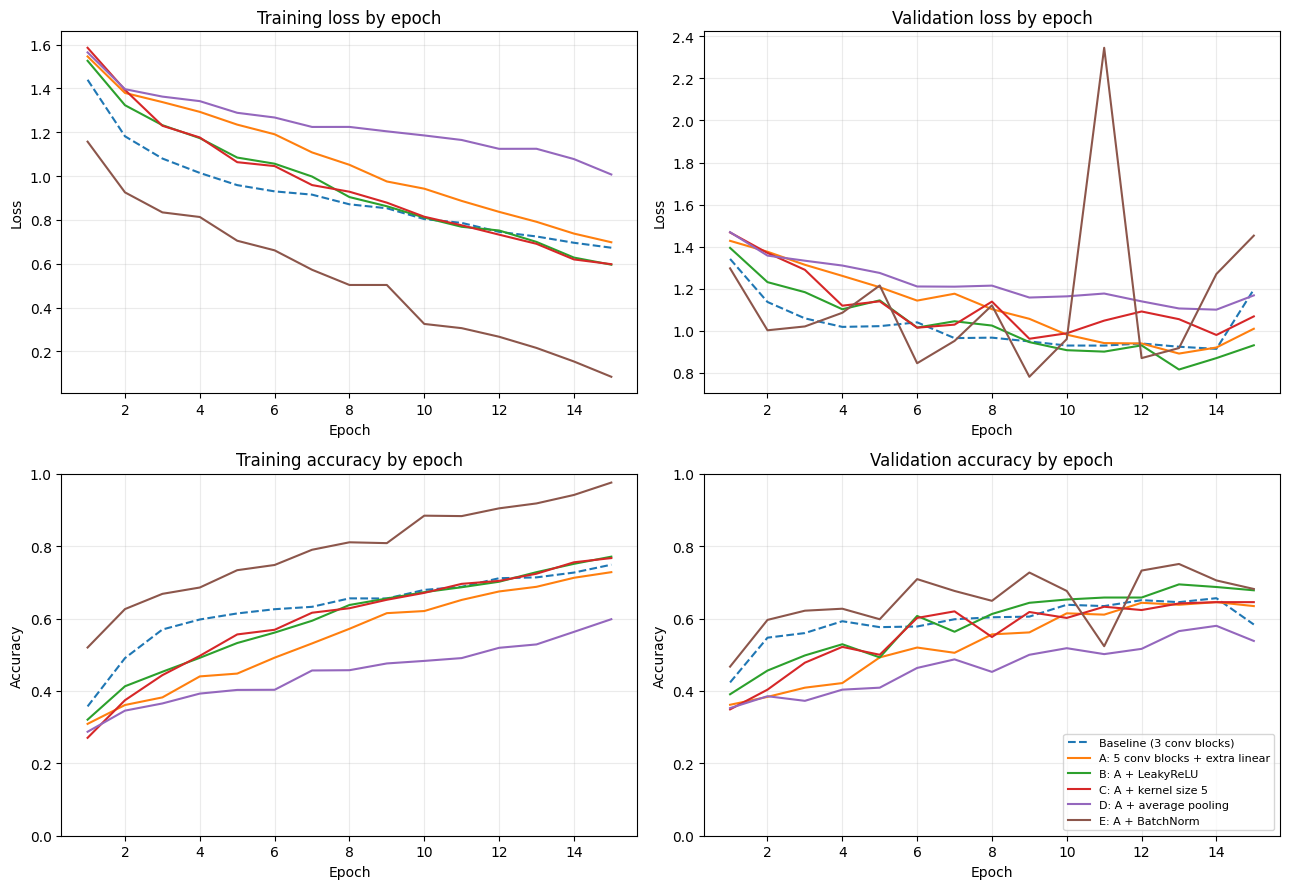

In [18]:
# Training and validation curves for the baseline and every experiment.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for name, h in histories.items():
    style = '--' if name.startswith('Baseline') else '-'
    axes[0, 0].plot(epochs, h['train_loss'], style, label=name)
    axes[0, 1].plot(epochs, h['val_loss'], style, label=name)
    axes[1, 0].plot(epochs, h['train_accuracy'], style, label=name)
    axes[1, 1].plot(epochs, h['val_accuracy'], style, label=name)
axes[0, 0].set(xlabel='Epoch', ylabel='Loss', title='Training loss by epoch')
axes[0, 1].set(xlabel='Epoch', ylabel='Loss', title='Validation loss by epoch')
axes[1, 0].set(xlabel='Epoch', ylabel='Accuracy', title='Training accuracy by epoch', ylim=(0, 1))
axes[1, 1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation accuracy by epoch', ylim=(0, 1))
for ax in axes.flat:
    ax.grid(alpha=0.25)
axes[1, 1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 11. Documentation of experiments

Results at each model's selected epoch (lowest validation loss), plus training and validation accuracy after all 15 epochs:

| Experiment | Params | Selected epoch | Val loss | Val acc | Train acc | Gap | Train acc @15 | Val acc @15 |
|---|---|---|---|---|---|---|---|---|
| Baseline (3 conv blocks) | 286,117 | 14 | 0.913 | 65.6% | 72.7% | 7.1% | 74.9% | 58.4% |
| A: 5 conv blocks + extra linear | 532,389 | 13 | 0.891 | 63.8% | 68.8% | 5.0% | 72.8% | 63.5% |
| B: A + LeakyReLU | 532,389 | 13 | 0.815 | 69.5% | 72.8% | 3.4% | 77.1% | 67.8% |
| C: A + kernel size 5 | 1,229,477 | 9 | 0.961 | 61.8% | 65.2% | 3.4% | 76.7% | 64.5% |
| D: A + average pooling | 532,389 | 14 | 1.100 | 58.0% | 56.3% | −1.7% | 59.8% | 53.8% |
| **E: A + BatchNorm** | 533,381 | 9 | **0.780** | **72.7%** | **80.8%** | 8.1% | **97.6%** | 68.2% |

**A: deeper network (2 more conv blocks + 1 more linear layer with ReLU).** Making the network deeper improved validation loss (0.913 → 0.891) and shrank the gap between training and validation accuracy (7.1% → 5.0%), but validation accuracy (63.8% vs 65.6%) and training accuracy (68.8% vs 72.7% at the selected epoch; 72.8% vs 74.9% after 15 epochs) went down. A deeper network has more layers for the gradient to pass through, so it learns more slowly: within 15 epochs it did not fit the training data as well as the smaller baseline. After 15 epochs, though, it holds up better on validation images than the baseline (63.5% vs 58.4%).

**B: activation function (LeakyReLU instead of ReLU).** This improved on A in every measure: validation loss 0.815, validation accuracy 69.5% (baseline 65.6%), training accuracy 72.8% at the selected epoch and 77.1% after 15 epochs (baseline 74.9%), with the smallest gap of the runs that are not underfitting (3.4%). ReLU outputs exactly zero for negative inputs, so some units can stop learning; LeakyReLU keeps a small slope for negative inputs, so more units keep learning.

**C: kernel size (5×5 instead of 3×3).** This made results worse: validation loss 0.961 and validation accuracy 61.8%, both worse than the baseline. 5×5 kernels more than double the number of parameters (532K → 1.23M). Its validation loss stopped improving early (selected epoch 9), while its training accuracy kept climbing to 76.7% by epoch 15: the model started memorizing the training images sooner than the others, which is overfitting. With small 64×64 images, stacked 3×3 kernels work better.

**D: pooling type (average pooling instead of max pooling).** This was the worst run: validation loss 1.100, validation accuracy 58.0%, and training accuracy only 56.3% at the selected epoch (59.8% after 15 epochs; 53.8% validation accuracy). Training accuracy is below validation accuracy (gap −1.7%), so the model is underfitting: it learns too slowly. Average pooling blurs each 2×2 region, while max pooling keeps the strongest edge or texture response, which is what distinguishes the flowers.

**E: new layer type (BatchNorm after each convolution).** This solved the slow-learning problem from A. BatchNorm normalizes each convolution's outputs, which keeps the signal well-scaled as it passes through the deeper network, so it trains much faster: training accuracy after 15 epochs jumped to 97.6% (baseline 74.9%). At its selected epoch (9) it has the best results of all runs: **training accuracy 80.8% (baseline 72.7%), validation accuracy 72.7% (baseline 65.6%), validation loss 0.780 (baseline 0.913)**.

**Overfitting checks.**
- Every run keeps the weights from its lowest-validation-loss epoch. The Val acc @15 column shows why: if training simply ran to epoch 15, validation accuracy would drop for the baseline (65.6% → 58.4%) and for E (72.7% → 68.2%), while E's training accuracy climbs to 97.6% (a 29.4% gap). That is overfitting, and those later epochs are not used. The same applies to C after epoch 9.
- At the selected epochs, A, B, C and D have a smaller train/validation gap than the baseline (5.0%, 3.4%, 3.4%, −1.7% vs 7.1%). E's gap is 1 point larger (8.1% vs 7.1%), but its validation accuracy is 7.1 points higher and its validation loss is the lowest of all runs, so it generalizes better than the baseline, not worse.

**Conclusion.**
- The best model is **E: the deeper network (5 conv blocks + extra linear layer with ReLU) with BatchNorm**, selected by lowest validation loss. Compared with the baseline, it improves training accuracy (72.7% → 80.8%), validation accuracy (65.6% → 72.7%) and validation loss (0.913 → 0.780).
- The "75%" quoted for the original model is its training accuracy after 15 epochs (74.9% here). The deeper network with BatchNorm can fit the training images far better (97.6% after 15 epochs), but that is the overfitting regime (validation accuracy falls to 68.2%), which is why the model from epoch 9 is used instead.
- What helped: LeakyReLU and above all BatchNorm (needed for the deeper network to train quickly). Depth alone (A) reduced overfitting and validation loss but did not raise accuracy within 15 epochs. What hurt: 5×5 kernels (early overfitting) and average pooling (underfitting).

**Problem 3.** In the 3_Visualizing_Flower_CNN_Filters_PyTorch.ipynb we did an introspection of how a Daisy image moves through a CNN and what feature maps are created at every block. Now, we have increased the depth of network in problem 2 above, we added 2 more convolutional layers (blocks) also added one linear layer with Relu activation as well. Make all these changs here in this notebook as well and load our new weights. And make sure we can still visualize the daisy. Notice our Dataset has Roses and tulips and other flowers, pick any two other flowers types and see how their feature maps look at last block. Also generate grad-CAM heatmap for both flowers and see if it truly highlights what makes up that image as a flower.

## 1. Save and load our new weights

We save the best Problem 2 model (**E: A + BatchNorm**) as a checkpoint, then load it the same way as the Visualizing notebook. The only change is the architecture: `DeeperCNN` (5 conv blocks + the extra linear layer with ReLU, `batch_norm=True`) replaces `BasicCNN`.

**Layer positions.** `model.features` is an ordered list of layers, and `print(model)` numbers them starting from 0. A number in brackets picks one layer by its position, just like picking an item from a Python list: `model.features[16]` is layer number 16.

Each block now has 4 layers (Conv2d → BatchNorm2d → ReLU → MaxPool2d), so the 5 blocks make 20 layers, numbered 0–19:

| Block | Conv2d | BatchNorm2d | ReLU | MaxPool2d |
|---|---|---|---|---|
| 1 | 0 | 1 | 2 | 3 |
| 2 | 4 | 5 | 6 | 7 |
| 3 | 8 | 9 | 10 | 11 |
| 4 | 12 | 13 | 14 | 15 |
| 5 (last) | **16** | **17** | **18** | **19** |

The first 4 blocks use layers 0–15, so the last block starts at 16. The later code uses these positions:
- `model.features[:19]` runs layers 0 up to 18 (the end number is not included). It stops right after the last block's ReLU, giving the last block's feature maps (256 maps of 4×4).
- `model.features[19]` runs only the final MaxPool layer.

In the Visualizing notebook, `BasicCNN` had 3 blocks of 3 layers (no BatchNorm), so its last block was at positions 6–8 and the code used `features[:8]` and `features[8]`.

In [21]:
# Save our new weights: the best Problem 2 model (E: A + BatchNorm).
checkpoint_path = PROJECT_DIR / 'outputs' / 'flowers_deeper_cnn.pth'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({'state_dict': model.state_dict(), 'class_names': class_names, 'image_size': IMAGE_SIZE},
           checkpoint_path)
print('Saved', best_name, 'to', checkpoint_path)

# Load them into the deeper CNN (DeeperCNN replaces BasicCNN from the Visualizing notebook).
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
model = DeeperCNN(len(checkpoint['class_names']), batch_norm=True)
model.load_state_dict(checkpoint['state_dict'])
model.eval()  # Prediction mode: BatchNorm uses the averages learned during training.
print(model)

Saved E: A + BatchNorm to /content/drive/MyDrive/AI/Flowers_CNN/outputs/flowers_deeper_cnn.pth
DeeperCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

## 2. Visualize the daisy

Same steps as the Visualizing notebook: take the first daisy photo, prepare it as during training (64×64, pixels 0–1), walk it through `model.features` keeping the maps after each ReLU, and show them. The daisy now passes through **5 blocks**, so the maps are 64×64, 32×32, 16×16, **8×8 and 4×4**, with 16, 32, 64, **128 and 256** channels (the first 64 channels of each block are shown).

Image: 100080576_f52e8ee070_n.jpg


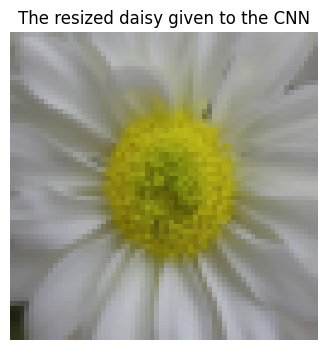

Block 1 | Conv2d      -> (1, 16, 64, 64)
Block 1 | BatchNorm2d -> (1, 16, 64, 64)
Block 1 | ReLU        -> (1, 16, 64, 64)
Block 1 | MaxPool2d   -> (1, 16, 32, 32)
Block 2 | Conv2d      -> (1, 32, 32, 32)
Block 2 | BatchNorm2d -> (1, 32, 32, 32)
Block 2 | ReLU        -> (1, 32, 32, 32)
Block 2 | MaxPool2d   -> (1, 32, 16, 16)
Block 3 | Conv2d      -> (1, 64, 16, 16)
Block 3 | BatchNorm2d -> (1, 64, 16, 16)
Block 3 | ReLU        -> (1, 64, 16, 16)
Block 3 | MaxPool2d   -> (1, 64, 8, 8)
Block 4 | Conv2d      -> (1, 128, 8, 8)
Block 4 | BatchNorm2d -> (1, 128, 8, 8)
Block 4 | ReLU        -> (1, 128, 8, 8)
Block 4 | MaxPool2d   -> (1, 128, 4, 4)
Block 5 | Conv2d      -> (1, 256, 4, 4)
Block 5 | BatchNorm2d -> (1, 256, 4, 4)
Block 5 | ReLU        -> (1, 256, 4, 4)
Block 5 | MaxPool2d   -> (1, 256, 2, 2)
Predicted flower: daisy (85.6%)


In [22]:
image_path = sorted((flower_root / 'daisy').glob('*.jpg'))[0]  # First daisy photo in filename order.
with Image.open(image_path) as photo:
    input_tensor = image_transform(photo.convert('RGB')).unsqueeze(0)  # Same preparation as training: (1, 3, 64, 64).

print('Image:', image_path.name)
plt.figure(figsize=(4, 4))
plt.imshow(input_tensor[0].permute(1, 2, 0))  # Plotting uses height, width, channels.
plt.title('The resized daisy given to the CNN')
plt.axis('off')
plt.show()

# Follow the image through the model, keeping the feature maps after each ReLU.
feature_maps = {}
block_number = 0
with torch.no_grad():
    current = input_tensor
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            block_number += 1
        current = layer(current)
        print(f'Block {block_number} | {layer.__class__.__name__:11s} -> {tuple(current.shape)}')
        if isinstance(layer, nn.ReLU):
            feature_maps[f'Block {block_number} — after ReLU'] = current.clone()
    logits = model.classifier(current)

probabilities = torch.softmax(logits, dim=1)[0]
print('Predicted flower:', class_names[probabilities.argmax().item()], f'({probabilities.max().item():.1%})')

In [ ]:
maps_to_show = 64

for name, maps in feature_maps.items():
    maps = maps[0]  # Remove the batch dimension: (channels, height, width).
    count = min(maps_to_show, maps.shape[0])
    rows = (count + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(10, 2.6 * rows), squeeze=False, layout='constrained')
    upper_limit = max(maps[:count].max().item(), 1e-8)

    for ax in axes.flat:
        ax.axis('off')
    for channel, ax in enumerate(axes.flat[:count]):
        image = ax.imshow(maps[channel], cmap='viridis', vmin=0, vmax=upper_limit)
        ax.set_title(f'Channel {channel}')

    fig.colorbar(image, ax=axes, shrink=0.7, label='Activation after ReLU')
    fig.suptitle(f'Daisy, {name}: {maps.shape[0]} maps of {maps.shape[1]}×{maps.shape[2]} pixels')
    plt.show()

## 3. Two other flowers: feature maps at the last block

We pick **roses** and **tulips** (the first photo of each in filename order) and show their **block 5** feature maps (after ReLU, before pooling: `model.features[:19]`), the same first 64 channels as the daisy's block 5 above, so they can be compared channel by channel.

roses: 10090824183_d02c613f10_m.jpg


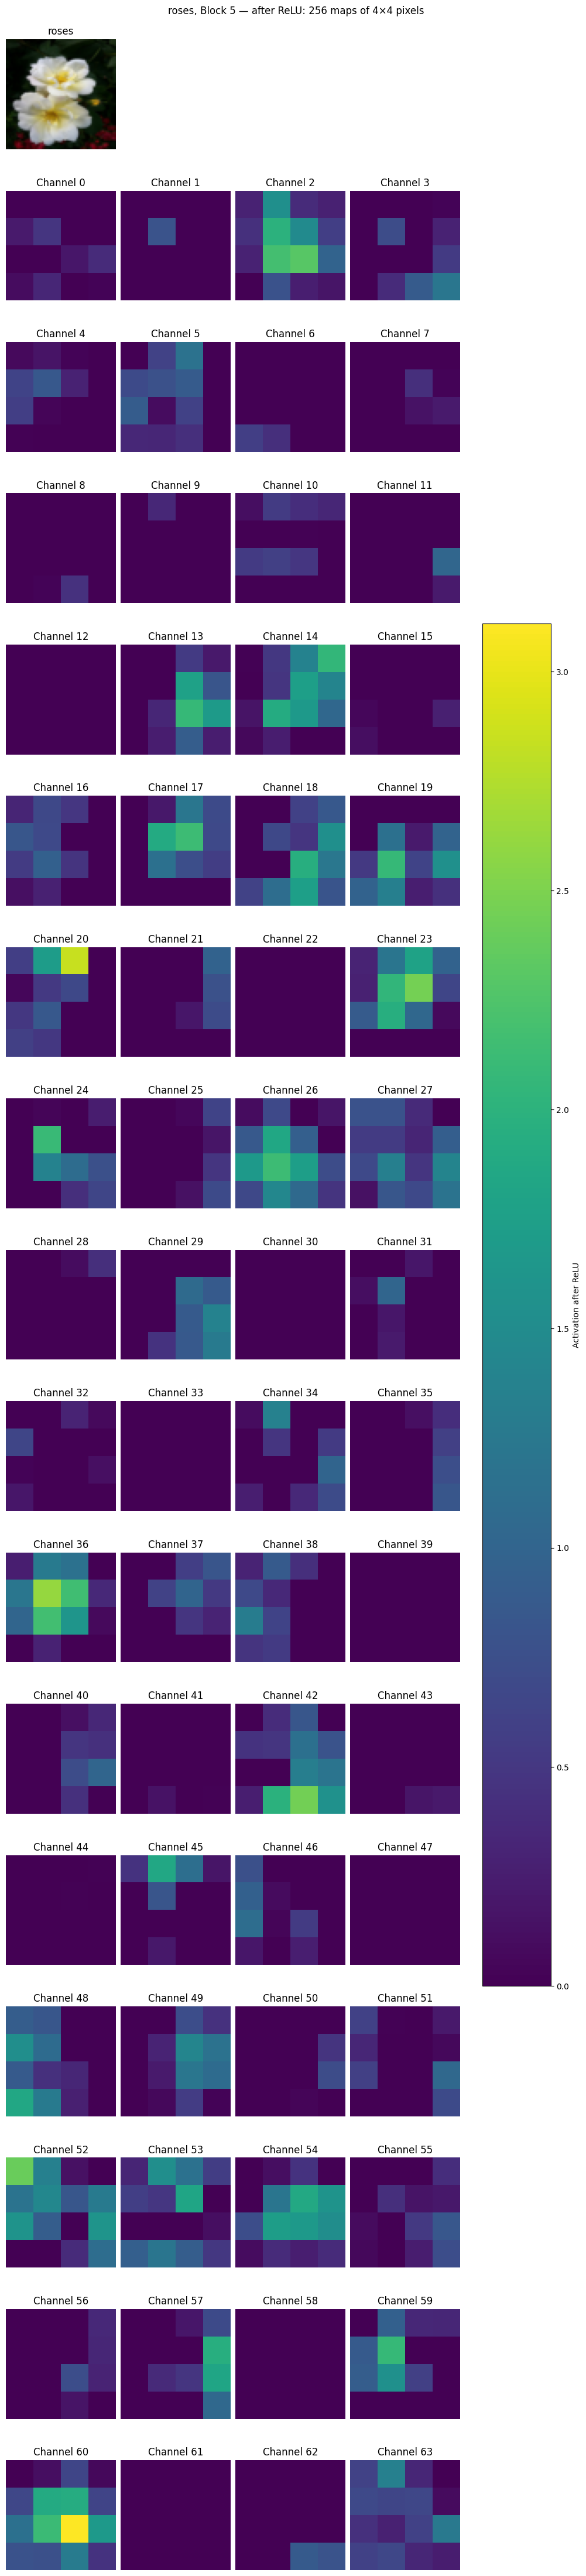

tulips: 100930342_92e8746431_n.jpg


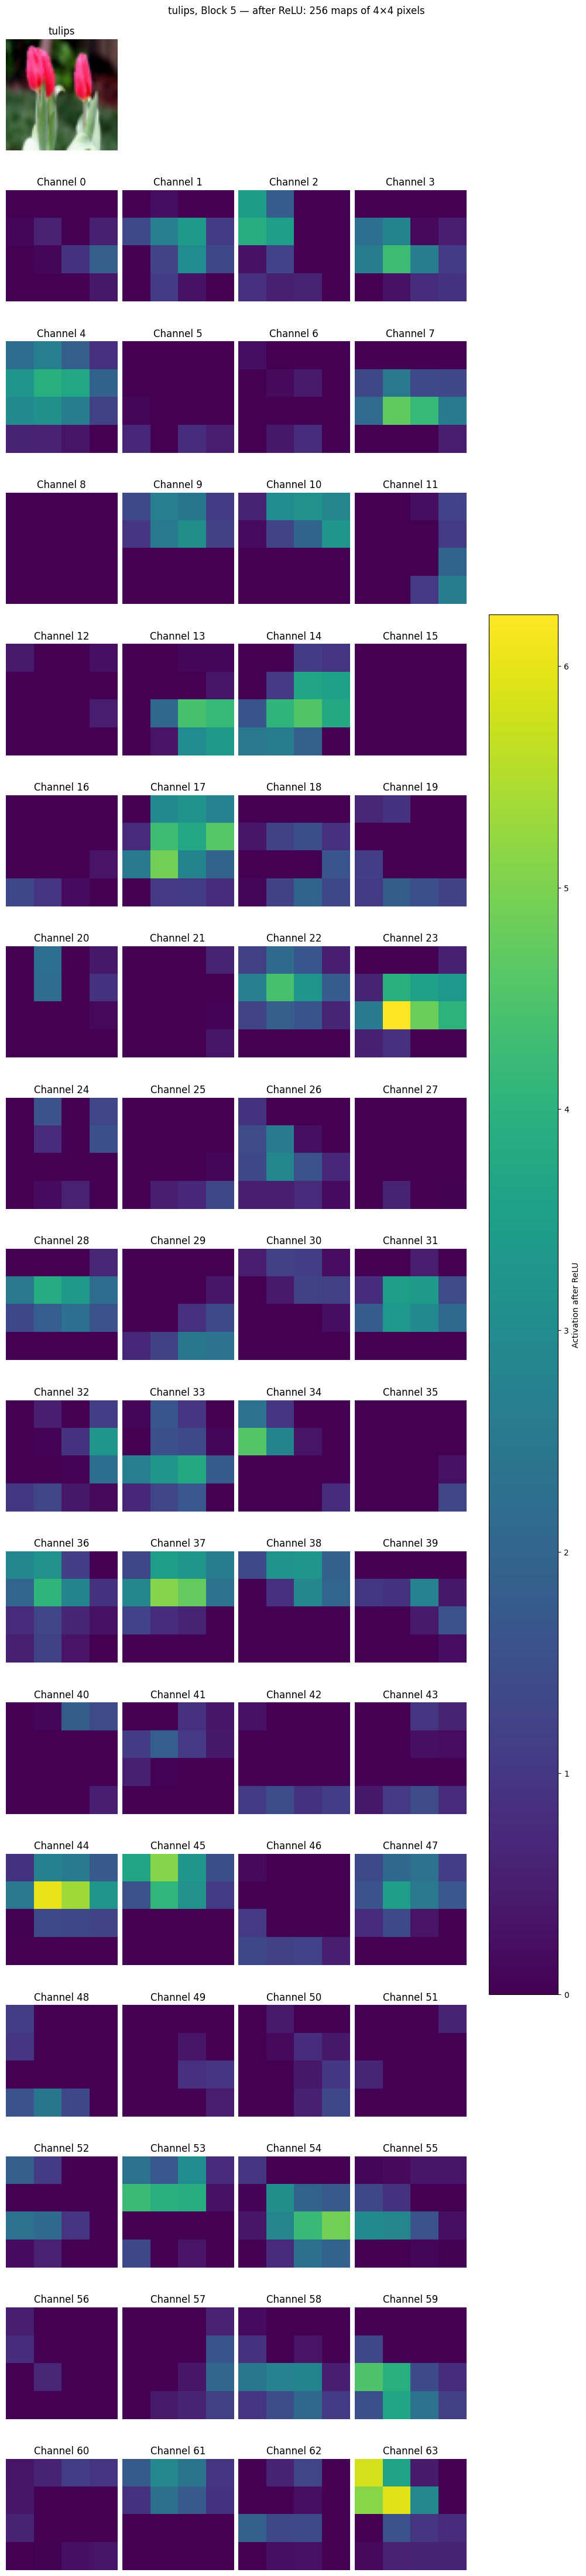

In [25]:
other_flowers = ['roses', 'tulips']  # Any two flower types other than daisy.
maps_to_show = 64  # Show the same first 64 channels as the daisy's block 5.
other_inputs = {}

for flower in other_flowers:
    flower_path = sorted((flower_root / flower).glob('*.jpg'))[0]  # First photo in filename order.
    with Image.open(flower_path) as photo:
        other_inputs[flower] = image_transform(photo.convert('RGB')).unsqueeze(0)

    with torch.no_grad():
        maps = model.features[:19](other_inputs[flower])[0]  # Block 5 after ReLU: (256, 4, 4).

    count = min(maps_to_show, maps.shape[0])
    rows = (count + 3) // 4
    fig, axes = plt.subplots(rows + 1, 4, figsize=(10, 2.6 * (rows + 1)), squeeze=False, layout='constrained')
    upper_limit = max(maps[:count].max().item(), 1e-8)

    for ax in axes.flat:
        ax.axis('off')
    print(f'{flower}: {flower_path.name}')
    axes[0, 0].imshow(other_inputs[flower][0].permute(1, 2, 0))  # First row: the flower itself.
    axes[0, 0].set_title(flower)
    for channel, ax in enumerate(axes.flat[4:4 + count]):
        image = ax.imshow(maps[channel], cmap='viridis', vmin=0, vmax=upper_limit)
        ax.set_title(f'Channel {channel}')

    fig.colorbar(image, ax=axes, shrink=0.7, label='Activation after ReLU')
    fig.suptitle(f'{flower}, Block 5 — after ReLU: {maps.shape[0]} maps of {maps.shape[1]}×{maps.shape[2]} pixels')
    plt.show()

## 4. Grad-CAM heatmaps for the two flowers

Same Grad-CAM as the Visualizing notebook, moved to our new last block: the maps after block 5's ReLU (`features[:19]`, 256 maps of 4×4), then the remaining pooling layer `features[19]` and the classifier. Each map is weighted by its average gradient for the predicted class score, the weighted maps are summed, negative values are removed, and the result is enlarged to 64×64 and scaled to 0–1.

Because the last block's maps are only 4×4, each heatmap cell covers a 16×16-pixel region, so the heatmap is coarse. Bright regions should fall on the petals and flower head (not the leaves, stems or background) if the model is really looking at the flower. The title shows the predicted class; if it is wrong, the heatmap explains the wrong class.

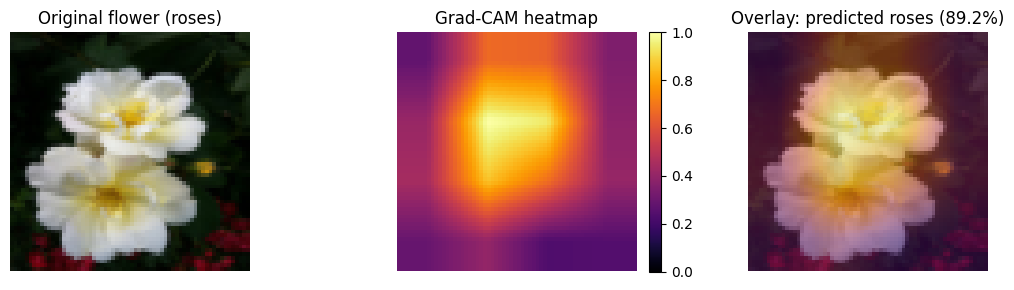

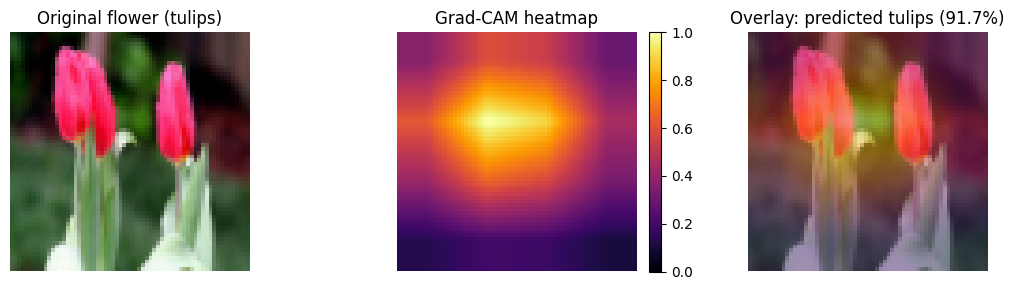

In [26]:
import torch.nn.functional as F

for flower in other_flowers:
    cam_input = other_inputs[flower].detach().clone().requires_grad_(True)
    maps = model.features[:19](cam_input)        # Block 5 conv + BatchNorm + ReLU: [1, 256, 4, 4].
    scores = model.classifier(model.features[19](maps))  # Remaining max-pooling, then one score per class.
    class_index = scores[0].argmax().item()      # Explain the predicted class.

    gradients = torch.autograd.grad(scores[0, class_index], maps)[0]
    weights = gradients.mean(dim=(2, 3), keepdim=True)            # One importance weight per map.
    heatmap = (weights * maps).sum(dim=1, keepdim=True).relu().detach()
    heatmap = F.interpolate(heatmap, size=cam_input.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
    heatmap = heatmap / heatmap.max().clamp(min=1e-8)             # Scale to 0–1.
    probability = torch.softmax(scores, dim=1)[0, class_index].item()

    flower_image = other_inputs[flower][0].permute(1, 2, 0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    axes[0].imshow(flower_image)
    axes[0].set_title(f'Original flower ({flower})')
    color_plot = axes[1].imshow(heatmap, cmap='inferno', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM heatmap')
    fig.colorbar(color_plot, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(flower_image)
    axes[2].imshow(heatmap, cmap='inferno', vmin=0, vmax=1, alpha=0.45)
    axes[2].set_title(f'Overlay: predicted {class_names[class_index]} ({probability:.1%})')
    for axis in axes:
        axis.axis('off')
    fig.tight_layout()
    plt.show()

## 5. Conclusion

The deeper model classifies all three flowers correctly: **daisy (85.6%)**, **roses (89.2%)** and **tulips (91.7%)**.

**Last-block feature maps.** At block 5 each map is only 4×4 (each value summarizes a 16×16-pixel region), so the maps no longer look like the flower. Many channels are completely dark for each flower, and different channels respond to each one: for roses, channels such as 2, 20, 36 and 60 are among the strongest; for tulips, channels 23, 44 and 63 (some, like 13 and 14, respond to both). The tulip activations are stronger (up to about 6 vs 3 for roses) and sit mostly in the upper and middle rows of the 4×4 maps, where the flower heads are. This different pattern of active channels is what the classifier uses to tell the flowers apart.

**Grad-CAM.**

- **Roses:** the heatmap is brightest on the flower heads (petals and yellow center), while the dark background and leaves stay dark. Grad-CAM **does highlight the flower**.
- **Tulips:** the heatmap is brightest in the upper middle, **between the two tulips**, and only partly covers the red flower heads; the stems and bottom stay dark. It finds the right area, but does not sharply outline the petals.

**Why the heatmaps are coarse:** in the deeper network the last block's maps are only 4×4 (vs 16×16 in the original), so each heatmap cell covers a 16×16-pixel region. Grad-CAM can show *roughly where* the evidence is, but not exact flower outlines.

**Summary:** we loaded the deeper Problem 2 model, followed the daisy through all 5 blocks, and compared the last-block feature maps of roses and tulips. Grad-CAM shows that both predictions are based on the flower region, not the background. This is clear for roses and partly true for tulips.